# Pelosi Alpha Capital

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from numba import njit, prange

In [2]:
# seed=42

The daatset has 102,198 lines and8 columns.  Each line represents a different trade.  There are 100 days of data, and roughly 1,000 trades per day. The columns contain information about the following variables:  
- (1) Day $d$ of the trade; 
- (2) Time $t$ of the trade, in seconds after midnight; 
- (3) Fundamental value $v_d$,tof the stock immediately after the trade; 
- (4) Ask price $A_{d,t}$; 
- (5) Bidprice $B_{d,t}$; 
- (6) Number of buy orders $Buys_{d,t}$; 
- (7) Number of sell orders $Sells_{d,t}$; 
- (8) Signal given by the data provider $s_{d,t}$.

In [3]:
path=r"data.csv" 
data=pd.read_csv(path)
new = 'day sec_post_midnight fund_post_trade ask bid n_buy_orders n_sell_orders signal'.split(' ')
old = list(data.columns)
data=data.rename({old[i]:col for i, col in enumerate(new)}, axis=1)

In [4]:
data['delta_fund_post_trade'] = data['fund_post_trade'] - data['fund_post_trade'].shift(1)
data['fund_post_trade_prev']=data['fund_post_trade'].shift(1)
data=data.dropna()
data.head(5)

,day,sec_post_midnight,fund_post_trade,ask,bid,n_buy_orders,n_sell_orders,signal,delta_fund_post_trade,fund_post_trade_prev
1,1,32406.147188,100.00,99.980000,99.980000,7,3,0,0.02,99.98
2,1,32409.115557,100.02,100.004000,99.996000,4,6,1,0.02,100.00
3,1,32471.025717,100.04,100.021333,100.018667,6,4,1,0.02,100.02
4,1,32473.743952,100.02,100.042000,100.038000,8,2,1,-0.02,100.04
5,1,32487.492880,100.04,100.020000,100.020000,5,5,0,0.02,100.02


In [5]:
def accuracy_indicator(row):
    if row['delta_fund_post_trade']>0 and row['signal']==1:
        return 1
    elif row['delta_fund_post_trade']<0 and row['signal']==0:
        return 1
    else:
        return 0

In [6]:
data['signal_accurate']=data.apply(lambda row: accuracy_indicator(row), axis=1)
tau = data['signal_accurate'].sum()/len(data)
step_size = np.abs(data['delta_fund_post_trade']).mean()

In [7]:
import numpy as np
import pandas as pd
from numba import njit

# 1. Core mathematical simulation compiled to C
@njit
def _core_sim(N_informed, tau, size, step_size, D, T, total_traders, v_0, S_0):
    N_uninformed = total_traders - N_informed
    threshold = (2.0 * tau - 1.0) * step_size
    profit = 0.0
    v_prev = float(v_0)
    
    for d in range(D):
        S_prev = float(S_0)
        cum_adverse_selection = 0.0
        
        for t in range(T):
            ask = v_prev + S_prev
            bid = v_prev - S_prev
            
            # C-level random selection
            step = step_size if np.random.random() < 0.5 else -step_size
            v_t = v_prev + step
            
            # Signal selection
            u = np.random.random()
            if step > 0:
                s = 1 if u < tau else 0
            else:
                s = 0 if u < tau else 1
                
            sells = np.random.binomial(N_uninformed, 0.5)
            buys = N_uninformed - sells
            
            if S_prev < threshold:
                if s == 1:
                    profit += (v_t - ask) * size
                    buys += N_informed
                elif s == 0:
                    profit += (bid - v_t) * size
                    sells += N_informed
                    
            v_prev = v_t
            cum_adverse_selection += step * (sells - buys)
            S_prev = max(0.0, -0.1 * cum_adverse_selection / (t + 1.0))
            
    return profit


# 2. Python wrapper preserving exact original functionality and signature
def exepcted_profit(N_informed, tau, size, step_size, seed=None, output='Numeric', D=100, T=1_000, total_traders=10, v_0=100, S_0=0):
    
    if N_informed < 1:
        print('There must be at least 1 informed trader')
        return

    # Seed handling specifically for NumPy/Numba compatibility
    if seed is not None and not pd.isna(seed):
        np.random.seed(seed)

    # Execute compiled logic
    profit = _core_sim(N_informed, tau, size, step_size, D, T, total_traders, v_0, S_0)

    # Preserve exact output formatting logic
    if output == 'DataFrame':
        N_uninformed = total_traders - N_informed
        results = pd.DataFrame({
            'Signal Accuracy': "{0:0.4f}".format(tau), 
            'Informed Traders': N_informed,
            'Uninformed Traders': N_uninformed,
            'Expected Profit (USD)': "{0:0.0f}".format(profit)
        }, index=['']).T
        return results 
        
    elif output == 'Numeric':
        return profit

### Single Informed Trader (10 in Total)

In [8]:
min_order = 10_000  # Minimum order size
results1 = exepcted_profit(N_informed=1, 
                           tau=tau, 
                           size=min_order, 
                           step_size=step_size,
                           output='DataFrame')
print(results1)

                              
Signal Accuracy         0.5967
Informed Traders             1
Uninformed Traders           9
Expected Profit (USD)  3443602


Since we have information on neither the risk aversion nor the capitalisaiton of the fund, the expected profit is a reasonable price quote.

### Two Informed Traders (10 in Total)

In [9]:
min_order = 10_000  # Minimum order size
results2 = exepcted_profit(N_informed=2, 
                           tau=tau, 
                           size=min_order, 
                        #    seed=seed, 
                           step_size=step_size,
                           output='DataFrame')
print(results2)

                              
Signal Accuracy         0.5967
Informed Traders             2
Uninformed Traders           8
Expected Profit (USD)  3114938


### Expected Profit vs Informed Traders - Monte Carlo

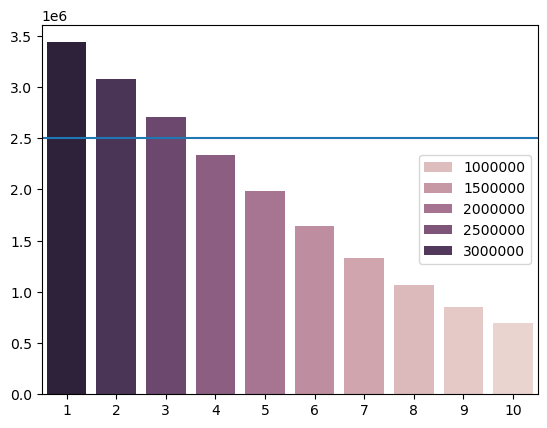

In [10]:
results3=[]
ids=[]
sims=1000
for N in range(10):
   results_mc=[]
   for _ in range(sims):
      results_mc.append(
         exepcted_profit(N_informed=N+1, 
                              tau=tau, 
                              size=min_order, 
                              step_size=step_size)
                              )
   results_mc = np.array(results_mc)
   results3.append(results_mc.mean())
   ids.append(N+1)

   data_price = 2_500_000

sns.barplot(x=ids, y=results3, hue=results3)
plt.axhline(data_price)

In [13]:
pd.DataFrame({'N_informed':ids, 'Expected Profit':results3})

,N_informed,Expected Profit
0,1,3.437423e+06
1,2,3.080747e+06
2,3,2.707339e+06
3,4,2.340669e+06
4,5,1.980656e+06
5,6,1.641433e+06
6,7,1.328321e+06
7,8,1.064528e+06
8,9,8.538905e+05
9,10,6.948787e+05


Given a total of 10 groups, only 3 groups will buy the data; The expected profit exceeds data price with just 3 informed players. The fourth group in line will decide against the purchase since that would constitute a guaranteed loss on expectation. Assuming our funds is first, second or third in line, only 2 other groups will pay for the data. 

#### Why didn't we iterate over 30-sec periods, with limit of 1,000 trades, instead iterating over 100 trades?
Delaying a profitable trade is sub-optimal, because the future signal yields the same expected economic benefit as the current.
